In [1]:
from matplotlib import pyplot as plt
import numpy as np
import cv2
import os
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential
import tensorflow_hub as hub

In [2]:
from utils import (
    num_images_classes, 
    prepare_data, 
    show_image_for_each_class,
    prepare_dataset_pipeline,
    split_dataset,
    DATASET,
    NUM_ClASSES,
    loss_accuracy_plot,
    DATA_AUGMENTATION,
)

In [9]:
num_images_classes()

3670 5


Prepare Dataset without Pipeline(Using cv2, numpy, sklearn)

In [10]:
X_train, X_test, y_train, y_test = prepare_data()
print(X_train.shape, y_train.shape)

(800, 180, 180, 3) (800,)


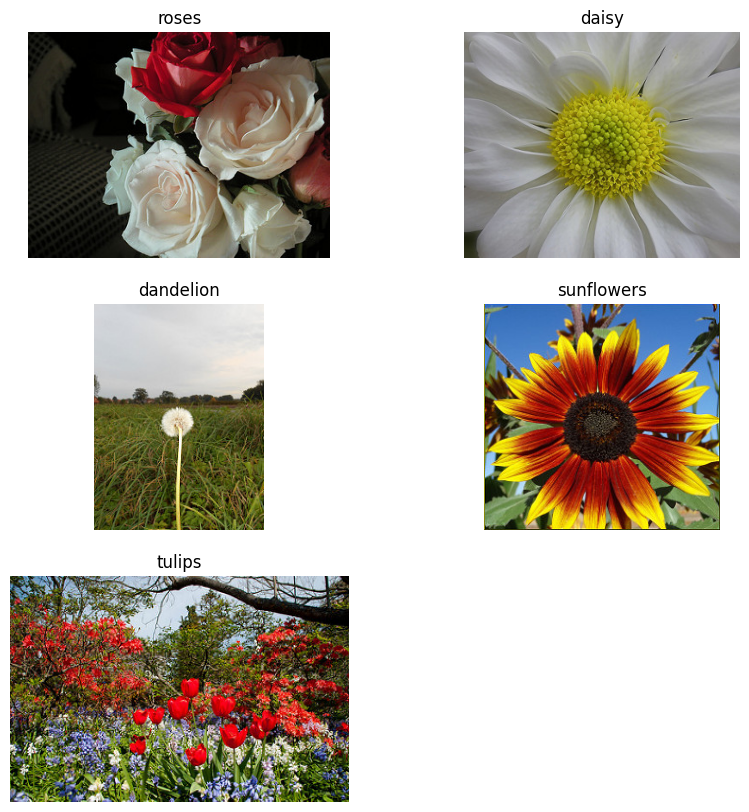

In [11]:
show_image_for_each_class()

Prepare Dataset Using Tensorflow Data Pipeline

In [43]:
train_dataset, test_dataset, val_dataset = split_dataset(DATASET)
train_dataset = prepare_dataset_pipeline(train_dataset, shuffle=True, batch_size=64)
test_dataset = prepare_dataset_pipeline(test_dataset, batch_size=64)    
val_dataset = prepare_dataset_pipeline(val_dataset, batch_size=64)

Model Using CNN

In [ ]:
model = Sequential([
    
    layers.Conv2D(16, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),
    layers.Conv2D(32, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),  
    layers.Conv2D(64, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),
    layers.Dropout(0.2),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(NUM_ClASSES)
])

model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])

In [ ]:
history = model.fit(X_train, y_train, epochs=20)
history

In [ ]:
loss_accuracy_plot(history)

In [14]:
model.evaluate(X_test, y_test)

7/7 ━━━━━━━━━━━━━━━━━━━━ 4s 290ms/step - accuracy: 0.5800 - loss: 1.7978


[1.797829270362854, 0.5799999833106995]

Training using Data Pipeline

In [5]:
model.evaluate(val_dataset)

12/12 ━━━━━━━━━━━━━━━━━━━━ 3s 93ms/step - accuracy: 0.1798 - loss: 1.6145


[1.6144869327545166, 0.17983651161193848]

In [6]:
history = model.fit(train_dataset, validation_data=val_dataset, epochs=10)
history

Epoch 1/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 31s 275ms/step - accuracy: 0.3696 - loss: 1.4090 - val_accuracy: 0.3706 - val_loss: 1.4199
Epoch 2/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 26s 261ms/step - accuracy: 0.5272 - loss: 1.1546 - val_accuracy: 0.5777 - val_loss: 1.0728
Epoch 3/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 26s 270ms/step - accuracy: 0.5875 - loss: 1.0361 - val_accuracy: 0.6049 - val_loss: 0.9695
Epoch 4/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 26s 271ms/step - accuracy: 0.6100 - loss: 0.9946 - val_accuracy: 0.6158 - val_loss: 0.8858
Epoch 5/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 32s 334ms/step - accuracy: 0.6247 - loss: 0.9323 - val_accuracy: 0.6621 - val_loss: 0.8399
Epoch 6/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 34s 349ms/step - accuracy: 0.6577 - loss: 0.8711 - val_accuracy: 0.6621 - val_loss: 0.8620
Epoch 7/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 34s 348ms/step - accuracy: 0.6638 - loss: 0.8537 - val_accuracy: 0.7139 - val_loss: 0.7626
Epoch 8/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 25s 259ms/step - accuracy: 0.6502 - loss: 0.8768 - val_accu

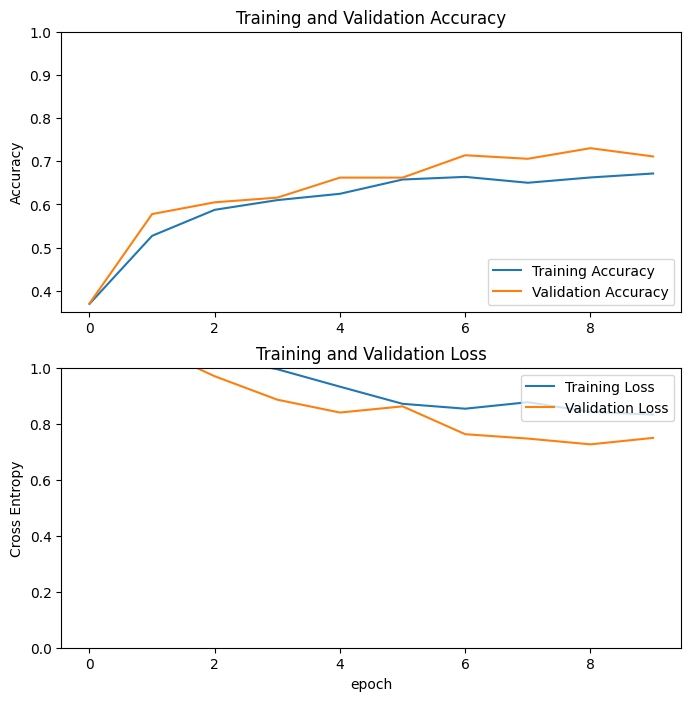

In [7]:
loss_accuracy_plot(history)

In [8]:
model.evaluate(test_dataset)

12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 61ms/step - accuracy: 0.7084 - loss: 0.7890


[0.7889876365661621, 0.7084468603134155]

Using Pre-trained Model

In [44]:
IMG_SIZE = (160, 160)
IMG_SHAPE = IMG_SIZE + (3,)
preprocess_input = tf.keras.applications.mobilenet_v2.preprocess_input
base_model = tf.keras.applications.MobileNetV2(input_shape=IMG_SHAPE,
                                               include_top=False,
                                               weights='imagenet')
base_model.trainable = False
base_model.summary()

Model: "mobilenetv2_1.00_160"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_6       │ (None, 160, 160,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 80, 80,    │        864 │ input_layer_6[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 80, 80,    │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 80, 80,    │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 80, 80,    │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 80, 80,    │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 80, 80,    │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 80, 80,    │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 80, 80,    │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 80, 80,    │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 80, 80,    │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 80, 80,    │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 81, 81,    │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 40, 40,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 40, 40,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 40, 40,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 40, 40,    │      2,304 │ block_1_depthwis

 Total params: 2,257,984 (8.61 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 2,257,984 (8.61 MB)

In [45]:
model = tf.keras.Sequential([
    tf.keras.layers.InputLayer(shape=IMG_SHAPE),
    DATA_AUGMENTATION,
    tf.keras.layers.Lambda(preprocess_input),
    base_model,
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(NUM_ClASSES),
])
model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lambda_2 (Lambda)               │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_160            │ (None, 5, 5, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 5)              │         6,405 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,264,389 (8.64 MB)

 Trainable params: 6,405 (25.02 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [46]:
len(model.trainable_variables)

2

In [47]:
len(base_model.layers)

154

In [48]:
model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])

In [49]:
model.evaluate(val_dataset)

6/6 ━━━━━━━━━━━━━━━━━━━━ 8s 816ms/step - accuracy: 0.2262 - loss: 2.3357


[2.3357291221618652, 0.2261580377817154]

In [50]:
history = model.fit(train_dataset, validation_data=val_dataset, epochs=10)

Epoch 1/10
46/46 ━━━━━━━━━━━━━━━━━━━━ 50s 940ms/step - accuracy: 0.2292 - loss: 1.7328 - val_accuracy: 0.2970 - val_loss: 1.5946
Epoch 2/10
46/46 ━━━━━━━━━━━━━━━━━━━━ 60s 1s/step - accuracy: 0.2251 - loss: 1.6669 - val_accuracy: 0.2779 - val_loss: 1.5961
Epoch 3/10
46/46 ━━━━━━━━━━━━━━━━━━━━ 56s 1s/step - accuracy: 0.2432 - loss: 1.6450 - val_accuracy: 0.3215 - val_loss: 1.5725
Epoch 4/10
46/46 ━━━━━━━━━━━━━━━━━━━━ 51s 1s/step - accuracy: 0.2544 - loss: 1.6237 - val_accuracy: 0.3243 - val_loss: 1.5411
Epoch 5/10
46/46 ━━━━━━━━━━━━━━━━━━━━ 55s 1s/step - accuracy: 0.2640 - loss: 1.6087 - val_accuracy: 0.2943 - val_loss: 1.5749
Epoch 6/10
46/46 ━━━━━━━━━━━━━━━━━━━━ 54s 1s/step - accuracy: 0.2701 - loss: 1.6118 - val_accuracy: 0.2643 - val_loss: 1.5985
Epoch 7/10
46/46 ━━━━━━━━━━━━━━━━━━━━ 61s 1s/step - accuracy: 0.2776 - loss: 1.5909 - val_accuracy: 0.2970 - val_loss: 1.5321
Epoch 8/10
46/46 ━━━━━━━━━━━━━━━━━━━━ 44s 940ms/step - accuracy: 0.2909 - loss: 1.5783 - val_accuracy: 0.3460 - val

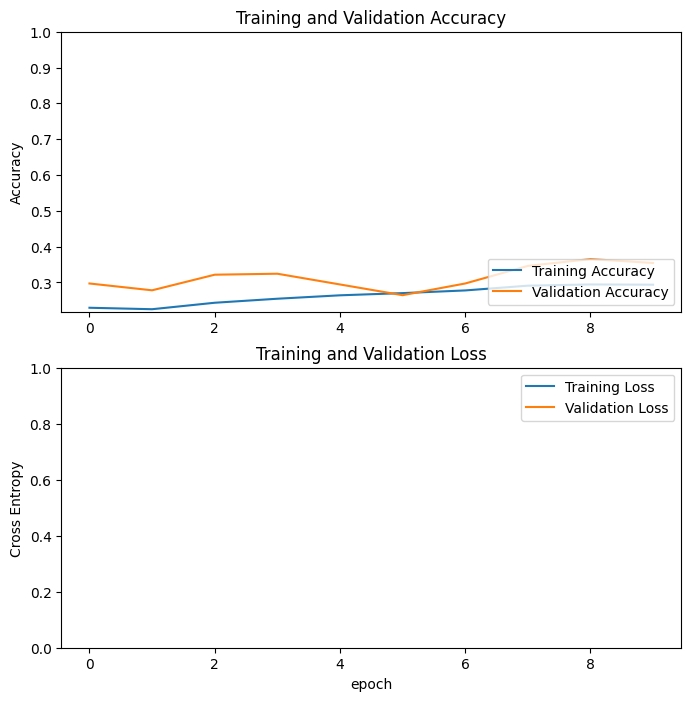

In [51]:
loss_accuracy_plot(history)

In [52]:
model.evaluate(test_dataset)

6/6 ━━━━━━━━━━━━━━━━━━━━ 6s 849ms/step - accuracy: 0.2916 - loss: 1.5562


[1.556218147277832, 0.2915531396865845]

Fine-Tuning

In [53]:
base_model.trainable = True

In [54]:
print("Number of layers in base model: ", len(base_model.layers))
for layer in base_model.layers[:130]:
    layer.trainable = False

Number of layers in base model:  154


In [55]:
model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lambda_2 (Lambda)               │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_160            │ (None, 5, 5, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 5)              │         6,405 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,277,201 (8.69 MB)

 Trainable params: 1,366,405 (5.21 MB)

 Non-trainable params: 897,984 (3.43 MB)

 Optimizer params: 12,812 (50.05 KB)

In [56]:
len(model.trainable_variables)  # 56

26

In [57]:
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=4e-5),
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])

In [58]:
fine_tune_epochs = 10
total_epochs =  10 + fine_tune_epochs

history_fine = model.fit(train_dataset,
                         epochs=total_epochs,
                         initial_epoch=len(history.epoch),
                         validation_data=val_dataset)

Epoch 11/20
46/46 ━━━━━━━━━━━━━━━━━━━━ 80s 2s/step - accuracy: 0.3082 - loss: 2.1251 - val_accuracy: 0.4196 - val_loss: 1.5004
Epoch 12/20
46/46 ━━━━━━━━━━━━━━━━━━━━ 85s 2s/step - accuracy: 0.3890 - loss: 1.4454 - val_accuracy: 0.3406 - val_loss: 1.5200
Epoch 13/20
46/46 ━━━━━━━━━━━━━━━━━━━━ 89s 2s/step - accuracy: 0.4138 - loss: 1.3909 - val_accuracy: 0.3106 - val_loss: 1.5782
Epoch 14/20
46/46 ━━━━━━━━━━━━━━━━━━━━ 85s 2s/step - accuracy: 0.4298 - loss: 1.3769 - val_accuracy: 0.3079 - val_loss: 1.5842
Epoch 15/20
46/46 ━━━━━━━━━━━━━━━━━━━━ 84s 2s/step - accuracy: 0.4394 - loss: 1.3478 - val_accuracy: 0.3433 - val_loss: 1.5749
Epoch 16/20
46/46 ━━━━━━━━━━━━━━━━━━━━ 79s 2s/step - accuracy: 0.4418 - loss: 1.3322 - val_accuracy: 0.3297 - val_loss: 1.5686
Epoch 17/20
46/46 ━━━━━━━━━━━━━━━━━━━━ 74s 2s/step - accuracy: 0.4414 - loss: 1.3399 - val_accuracy: 0.2916 - val_loss: 1.6492
Epoch 18/20
46/46 ━━━━━━━━━━━━━━━━━━━━ 74s 2s/step - accuracy: 0.4513 - loss: 1.3235 - val_accuracy: 0.2262 - v

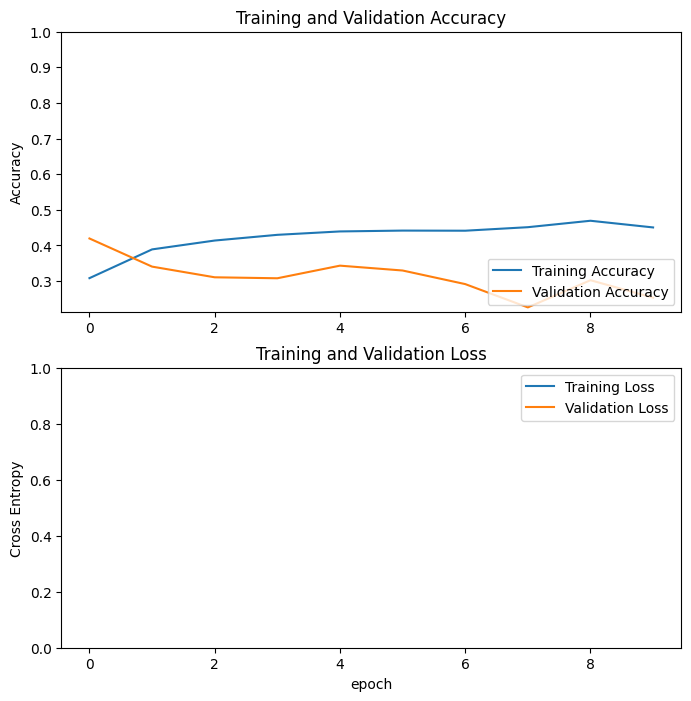

In [59]:
loss_accuracy_plot(history_fine)

Data Augmentation To prevent Overfitting

Using tf.image

In [ ]:
IMG_SIZE = 180
def augment(image_label, seed):
  image, label = image_label
  image = resize_rescale(image)
  image = tf.image.resize_with_crop_or_pad(image, IMG_SIZE + 6, IMG_SIZE + 6)
  # Make a new seed.
  new_seed = tf.random.split(seed, num=1)[0, :]
  # Random crop back to the original size.
  image = tf.image.stateless_random_crop(
      image, size=[IMG_SIZE, IMG_SIZE, 3], seed=seed)
  # Random brightness.
  image = tf.image.stateless_random_brightness(
      image, max_delta=0.5, seed=new_seed)
  image = tf.clip_by_value(image, 0, 1)
  return image, label

counter = tf.data.experimental.Counter()
train_ds = tf.data.Dataset.zip((train_dataset, (counter, counter)))

train_ds = (
    train_ds
    .shuffle(1000)
    .map(augment, num_parallel_calls=AUTOTUNE)
    .batch(32)
    .prefetch(AUTOTUNE)
)


ValueError: Exception encountered when calling Sequential.call().

[1mInvalid input shape for input [[[232. 201. 192.]
  [233. 204. 195.]
  [233. 206. 196.]
  ...
  [210. 176. 153.]
  [208. 174. 151.]
  [209. 172. 150.]]

 [[230. 201. 192.]
  [232. 205. 195.]
  [234. 207. 197.]
  ...
  [207. 174. 154.]
  [209. 176. 156.]
  [209. 176. 156.]]

 [[229. 204. 194.]
  [232. 207. 197.]
  [233. 208. 198.]
  ...
  [206. 174. 155.]
  [206. 174. 155.]
  [208. 175. 159.]]

 ...

 [[ 93. 121.  98.]
  [ 52.  80.  60.]
  [ 71. 104.  83.]
  ...
  [125. 158. 143.]
  [124. 157. 142.]
  [127. 160. 145.]]

 [[146. 176. 147.]
  [ 88. 119.  90.]
  [105. 140. 114.]
  ...
  [128. 161. 146.]
  [133. 166. 151.]
  [128. 159. 144.]]

 [[186. 212. 196.]
  [109. 135. 121.]
  [100. 130. 119.]
  ...
  [128. 162. 145.]
  [128. 160. 143.]
  [125. 157. 140.]]] with name 'keras_tensor_33' and path ''. Expected shape (None, 180, 180, 3), but input has incompatible shape (240, 320, 3)[0m

Arguments received by Sequential

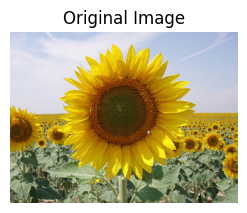

In [79]:
plt.figure(figsize=(10, 10))
plt.subplot(3, 3, 1)
plt.title('Original Image')
plt.imshow(plt.imread(str(sunflowers[1])))
plt.axis('off')

for i in range(2, 10):
     img = data_agmantation(cv2.imread(str(sunflowers[1])))
     plt.subplot(3, 3, i)
     plt.title('Augmented Image')
     plt.imshow(img.numpy().astype("uint8"))
     plt.axis('off')
    


In [14]:
model = Sequential([
    data_agmantation,
    layers.Conv2D(16, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),
    layers.Conv2D(32, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),  
    layers.Conv2D(64, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),
    layers.Dropout(0.2),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(num_clases)
])

model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])
model.fit(X_train, y_train, epochs=30)

Epoch 1/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 88s 2s/step - accuracy: 0.2700 - loss: 1.6657
Epoch 2/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 58s 2s/step - accuracy: 0.3950 - loss: 1.3882
Epoch 3/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 46s 2s/step - accuracy: 0.4575 - loss: 1.2027
Epoch 4/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 91s 2s/step - accuracy: 0.5150 - loss: 1.1949
Epoch 5/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 46s 2s/step - accuracy: 0.5050 - loss: 1.1295
Epoch 6/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 54s 2s/step - accuracy: 0.5525 - loss: 1.1271
Epoch 7/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 50s 2s/step - accuracy: 0.5663 - loss: 1.0415
Epoch 8/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 48s 2s/step - accuracy: 0.5600 - loss: 1.0524
Epoch 9/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 54s 2s/step - accuracy: 0.5900 - loss: 1.0059
Epoch 10/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 52s 2s/step - accuracy: 0.6025 - loss: 0.9634
Epoch 11/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 81s 2s/step - accuracy: 0.6025 - loss: 0.9475
Epoch 12/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 55s 2s/step - accuracy: 0.6388 - lo

In [15]:
model.evaluate(X_test, y_test)

7/7 ━━━━━━━━━━━━━━━━━━━━ 4s 294ms/step - accuracy: 0.6400 - loss: 0.8776


[0.8776121735572815, 0.6399999856948853]